# 04 — Escalamiento y PCA

**Objetivo:** Tomar las variables numéricas (`age`, `monthly_watch_time_mins`, `customer_support_tickets`), **estandarizarlas** con `StandardScaler` y aplicar **PCA** (Análisis de Componentes Principales) para reducir dimensiones, explicando por qué cada paso es necesario.

### ¿Por qué escalar antes de PCA?
PCA busca las direcciones de máxima **varianza**. Si las variables están en escalas distintas (la edad va de 13 a 80, pero el tiempo de visualización llega a ~2700), la variable de mayor magnitud domina artificialmente el análisis. Estandarizar (media 0, desvío 1) pone a todas en igualdad de condiciones para que PCA mida relaciones reales y no diferencias de unidad.

## Carga y selección de variables numéricas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/processed/streaming_users_clean.csv')

# Variables numéricas para el análisis
num_cols = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[num_cols].copy()
print("Variables seleccionadas:", num_cols)
X.head()

Variables seleccionadas: ['age', 'monthly_watch_time_mins', 'customer_support_tickets']


,age,monthly_watch_time_mins,customer_support_tickets
0,39.0,805.8,1
1,37.0,1173.4,2
2,28.0,401.0,0
3,43.0,62.4,0
4,51.0,477.8,1


## Paso 1 — Varianza antes de escalar

In [2]:
print("Varianza original (escalas muy distintas):")
print(X.var().round(2))

Varianza original (escalas muy distintas):
age                            131.23
monthly_watch_time_mins     185733.62
customer_support_tickets         0.80
dtype: float64


**Observación:** La varianza de `monthly_watch_time_mins` es de varios órdenes de magnitud mayor que la de `age` o `customer_support_tickets`, simplemente porque está medida en una escala más grande. Sin escalar, PCA pensaría que watch_time es "la variable más importante" solo por sus unidades. Por eso estandarizamos.

## Paso 2 — Estandarización (StandardScaler / Z-score)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols)

print("Varianza después de estandarizar (todas ≈ 1):")
print(X_scaled_df.var().round(4))
print("\nMedia después de estandarizar (todas ≈ 0):")
print(X_scaled_df.mean().round(4))

Varianza después de estandarizar (todas ≈ 1):
age                         1.0001
monthly_watch_time_mins     1.0001
customer_support_tickets    1.0001
dtype: float64

Media después de estandarizar (todas ≈ 0):
age                        -0.0
monthly_watch_time_mins     0.0
customer_support_tickets   -0.0
dtype: float64


**Qué se logró:** ahora las tres variables tienen media 0 y varianza ~1. Están en pie de igualdad: PCA ya no se dejará engañar por las unidades y medirá la estructura real de los datos.

### Consideraciones sobre el escalamiento (cuándo aplicarlo y con qué scaler)

Siguiendo el material de la cátedra, el escalamiento no es universal: depende del algoritmo y de los datos.

- **Cuándo escalar:** siempre que el algoritmo use **distancias** (PCA, K-Means, KNN, SVM) o **gradiente descendente** (redes neuronales, regresión regularizada). Como PCA se basa en la varianza/distancia, escalar es **obligatorio** acá. Sin escalar, la componente principal quedaría dominada por la variable de mayor magnitud (`monthly_watch_time_mins`), reflejando las **unidades** y no la estructura real de los datos.
- **Cuándo NO escalar:** en **árboles de decisión** y **Random Forest**, que dividen por umbrales independientes de la escala y no se ven afectados.
- **Por qué la misma unidad no basta:** lo que importa no es la unidad sino la **varianza**. Una variable que varía poco y otra que varía mucho son incomparables aunque compartan unidad. Por eso comparamos `var()` antes y después de estandarizar.
- **StandardScaler vs RobustScaler:** `StandardScaler` usa media y desvío, que son **sensibles a outliers** (un valor extremo distorsiona ambos). Cuando hay outliers fuertes, se recomienda `RobustScaler` (usa mediana e IQR). **En este proyecto** ya tratamos los valores extremos en la etapa de limpieza (valores imposibles → nulo y winsorización IQR k=3 del consumo), de modo que `StandardScaler` opera sobre datos ya saneados y su sensibilidad a outliers no es un problema. Si hubiéramos trabajado sobre los datos crudos, `RobustScaler` habría sido la opción más prudente.
- **Buena práctica (train/test):** cuando se entrena un modelo, el scaler se ajusta solo con datos de entrenamiento (`fit_transform`) y se aplica al test con `transform`, para no filtrar información del test. En este proyecto no entrenamos un modelo predictivo, así que aplicamos `fit_transform` sobre todo el conjunto con fines exploratorios/diagnósticos.

## Paso 3 — Aplicar PCA

In [4]:
pca = PCA(n_components=3)   # empezamos con todas las componentes para ver la varianza explicada
componentes = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

resumen = pd.DataFrame({
    'Componente': ['PC1','PC2','PC3'],
    'Varianza explicada %': (var_exp*100).round(2),
    'Varianza acumulada %': (var_acum*100).round(2)
})
print(resumen.to_string(index=False))

Componente  Varianza explicada %  Varianza acumulada %
       PC1                 33.75                 33.75
       PC2                 33.22                 66.96
       PC3                 33.04                100.00


## Paso 4 — Scree plot (varianza explicada por componente)

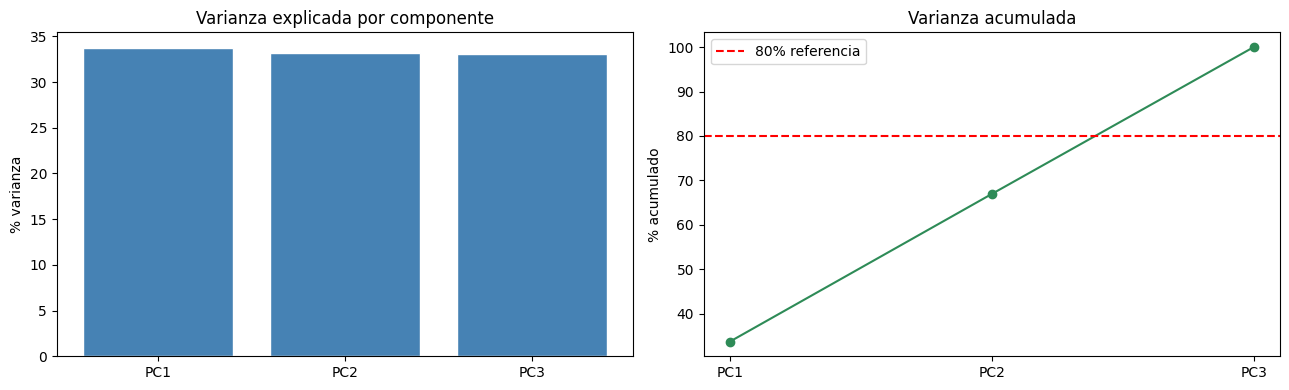

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].bar(['PC1','PC2','PC3'], var_exp*100, color='steelblue', edgecolor='white')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_ylabel('% varianza')

axes[1].plot(['PC1','PC2','PC3'], var_acum*100, marker='o', color='seagreen')
axes[1].axhline(80, color='red', linestyle='--', label='80% referencia')
axes[1].set_title('Varianza acumulada')
axes[1].set_ylabel('% acumulado'); axes[1].legend()

plt.tight_layout(); plt.show()

**Interpretación:** cada componente explica aproximadamente **un tercio** de la varianza total (~33% cada una). Esto es revelador: significa que las tres variables son **prácticamente independientes entre sí** — no hay redundancia que PCA pueda comprimir. En un dataset con variables correlacionadas (como Iris, donde largo y ancho de pétalo van juntos), las primeras componentes capturarían la mayor parte de la varianza. Acá, en cambio, no hay un "atajo": para conservar el 80% de la información hacen falta casi todas las componentes.

## Paso 5 — Cargas (loadings): qué variable pesa en cada componente

In [6]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2','PC3'], index=num_cols)
print("Cargas de cada variable en cada componente:")
print(loadings.round(3))

Cargas de cada variable en cada componente:
                            PC1    PC2    PC3
age                       0.646 -0.042  0.762
monthly_watch_time_mins   0.554 -0.661 -0.506
customer_support_tickets  0.525  0.749 -0.403


**Interpretación:** como las variables no están correlacionadas, cada componente principal tiende a alinearse con una variable distinta, en lugar de mezclar varias. Esto confirma que no hay una estructura latente que combine `age`, `watch_time` y `tickets`.

## Paso 6 — Matriz de correlación (Heatmap)

El resultado del PCA (cada componente ~33%) se explica mirando la **correlación** entre las variables.
Visualizamos la matriz con un *heatmap* para confirmar el diagnóstico.

                            age  monthly_watch_time_mins  \
age                       1.000                    0.008   
monthly_watch_time_mins   0.008                    1.000   
customer_support_tickets  0.007                    0.004   

                          customer_support_tickets  
age                                          0.007  
monthly_watch_time_mins                      0.004  
customer_support_tickets                     1.000  


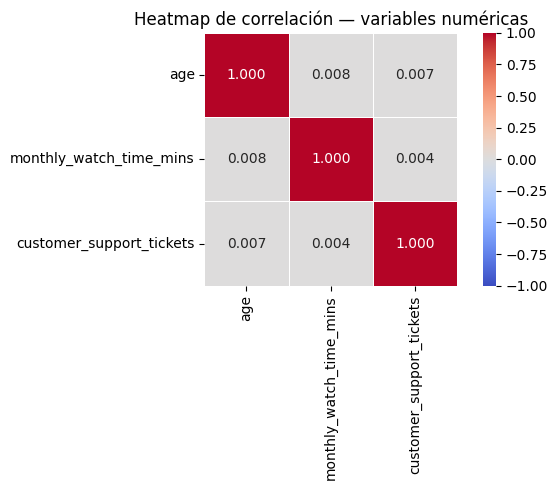

In [7]:
import seaborn as sns

corr = df[num_cols].corr()
print(corr.round(3))

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True,
            fmt='.3f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap de correlación — variables numéricas')
plt.tight_layout(); plt.show()

**Interpretación:** todas las correlaciones fuera de la diagonal son **cercanas a cero** (entre 0.004 y 0.008). Esto confirma que `age`, `monthly_watch_time_mins` y `customer_support_tickets` **no tienen relación lineal entre sí**, y es exactamente la razón por la que el PCA no logra comprimir: no hay redundancia que reducir. Es el resultado opuesto a un dataset como Iris (donde variables muy correlacionadas permiten que una sola componente capture casi toda la varianza).

## Conclusión del PCA

**¿Por qué hicimos esto?** Para verificar si las variables numéricas podían reducirse a menos dimensiones sin perder información, lo que simplificaría análisis o modelos posteriores y evitaría redundancia (multicolinealidad).

**¿Qué encontramos?** Que **en este dataset no conviene reducir dimensiones**: las tres variables son independientes (cada componente explica ~33%), así que descartar componentes perdería información real. PCA aquí cumple un rol **diagnóstico**: nos confirma que `age`, `watch_time` y `tickets` aportan información distinta y deben conservarse todas.

**Lección metodológica:** PCA no siempre reduce dimensiones; a veces su mayor valor es **revelar la estructura (o ausencia de estructura) de correlación** entre variables. Un resultado de "no se puede comprimir" es un hallazgo válido, no un fracaso del método.